In [ ]:
import warnings
warnings.simplefilter("ignore")


import numpy as np
import pandas as pd
from datetime import datetime
import re


import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from IPython.display import HTML
import json


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

### Dataset Initialization

In [2]:
result_df = pd.read_csv('formula-1-world-championship-1950-2020/results.csv') 
qualifying_df = pd.read_csv('formula-1-world-championship-1950-2020/qualifying.csv')
pit_stops_df = pd.read_csv('formula-1-world-championship-1950-2020/pit_stops.csv')
drivers_df = pd.read_csv('formula-1-world-championship-1950-2020/drivers.csv')
races_df = pd.read_csv('formula-1-world-championship-1950-2020/races.csv')
constructor_df = pd.read_csv('formula-1-world-championship-1950-2020/constructors.csv')
driver_standings_df = pd.read_csv('formula-1-world-championship-1950-2020/driver_standings.csv')
constructor_standings_df = pd.read_csv('formula-1-world-championship-1950-2020/constructor_standings.csv')
circuits_df = pd.read_csv('formula-1-world-championship-1950-2020/circuits.csv')
lap_times_df = pd.read_csv('formula-1-world-championship-1950-2020/lap_times.csv')
sprint_results_df = pd.read_csv('formula-1-world-championship-1950-2020/sprint_results.csv')

### Dataset Information

In [3]:
datasets = {
    "Results": result_df,
    "Races": races_df,
    "Drivers": drivers_df,
    "Constructors": constructor_df,
    "Qualifying": qualifying_df,
    "Pit Stops": pit_stops_df,
    "Driver Standings": driver_standings_df,
    "Constructor Standings": constructor_standings_df,
    "Circuits": circuits_df,
    "Lap Times": lap_times_df,
    "Sprint Results": sprint_results_df
}

for name, df in datasets.items():
    print("\n" + "="*70)
    print(f"DATASET: {name}")
    print("="*70)
    df.info()


DATASET: Results
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         26759 non-null  int64  
 1   raceId           26759 non-null  int64  
 2   driverId         26759 non-null  int64  
 3   constructorId    26759 non-null  int64  
 4   number           26759 non-null  object 
 5   grid             26759 non-null  int64  
 6   position         26759 non-null  object 
 7   positionText     26759 non-null  object 
 8   positionOrder    26759 non-null  int64  
 9   points           26759 non-null  float64
 10  laps             26759 non-null  int64  
 11  time             26759 non-null  object 
 12  milliseconds     26759 non-null  object 
 13  fastestLap       26759 non-null  object 
 14  rank             26759 non-null  object 
 15  fastestLapTime   26759 non-null  object 
 16  fastestLapSpeed  26759 non-null  object 

# FEATURE ENGINEERING

### Target Variable Creation

In [4]:
result_df['position_num'] = pd.to_numeric(result_df['position'], errors='coerce')
result_df['podium'] = (result_df['position_num'] <= 3).astype(int) # 1 for podium finish, 0 otherwise
print(result_df['podium'].value_counts())
print(result_df['podium'].dtype)

podium
0    23363
1     3396
Name: count, dtype: int64
int64


### Feature Renaming

In [5]:
qualifying_df = qualifying_df.rename(columns={'position': 'quali_position'})
constructor_df = constructor_df.rename(columns={'nationality': 'construct_nationality'})

#### Check for duplicates

In [6]:
result_df = result_df.sort_values('position_num').drop_duplicates(subset=['raceId', 'driverId'], keep='first')
print("result_df dupes after fix:", result_df.duplicated(subset=['raceId', 'driverId']).sum())

result_df dupes after fix: 0


In [7]:
qualifying_df = qualifying_df.sort_values('quali_position').drop_duplicates(subset=['raceId', 'driverId'], keep='first')

In [8]:
print("result_df dupes:", result_df.duplicated(subset=['raceId', 'driverId']).sum())
print("qualifying_df dupes:", qualifying_df.duplicated(subset=['raceId', 'driverId']).sum())
print("drivers_df dupes:", drivers_df.duplicated(subset=['driverId']).sum())
print("constructor_df dupes:", constructor_df.duplicated(subset=['constructorId']).sum())
print("races_df dupes:", races_df.duplicated(subset=['raceId']).sum())

result_df dupes: 0
qualifying_df dupes: 0
drivers_df dupes: 0
constructor_df dupes: 0
races_df dupes: 0


### Merging of Result, Races, Qualifying, Constructor, Drivers Datasets

In [9]:
print("Results year range:",
      races_df.merge(result_df, on='raceId')['year'].min(),
      races_df.merge(result_df, on='raceId')['year'].max())

print("Races year range:",
      races_df['year'].min(),
      races_df['year'].max())

Results year range: 1950 2024
Races year range: 1950 2024


In [10]:
df = (
    result_df
    .merge(races_df[['raceId', 'year', 'round', 'circuitId', 'name', 'date']], on='raceId', how='left')
    .merge(qualifying_df[['raceId', 'driverId', 'quali_position']], on=['raceId','driverId'], how='left')
    .merge(constructor_df[['constructorId', 'construct_nationality']], on='constructorId', how='left')
    .merge(drivers_df[['driverId', 'nationality', 'dob','forename','surname']], on='driverId', how='left')
)

In [11]:
print("After base merge:", df.shape, "| Dupes:", df.duplicated(subset=['raceId','driverId']).sum())

After base merge: (26668, 31) | Dupes: 0


### Feature Datatype Change

In [12]:
print(df['grid'].dtype)
print(df['dob'].dtype)
print(df['date'].dtype)
print(df['time'].dtype)

int64
object
object
object


In [13]:
df['grid'] = pd.to_numeric(df['grid'], errors='coerce')
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
print(df['grid'].dtype)
print(df['dob'].dtype)
print(df['date'].dtype)

int64
datetime64[ns]
datetime64[ns]


In [14]:
def convert_time_to_ms(val):

    if not isinstance(val, str):
        return val
   
    match = re.match(r'^(\d+):(\d+):(\d+\.\d+)$', val)
    if match:
        h, m, s = match.groups()
        return (int(h) * 3600 + int(m) * 60 + float(s)) * 1000
    match = re.match(r'^(\d+):(\d+\.\d+)$', val)
    if match:
        m, s = match.groups()
        return (int(m) * 60 + float(s)) * 1000
    return val 

### New Feature Driver Age (in each Race)

In [15]:
df[['name','date']]

,name,date
0,Australian Grand Prix,2008-03-16
1,South African Grand Prix,1967-01-02
2,Spanish Grand Prix,2002-04-28
3,Monaco Grand Prix,1967-05-07
4,Dutch Grand Prix,1967-06-04
...,...,...
26663,Qatar Grand Prix,2024-12-01
26664,Qatar Grand Prix,2024-12-01
26665,Abu Dhabi Grand Prix,2024-12-08
26666,Abu Dhabi Grand Prix,2024-12-08


In [16]:
df['driver_age'] = (df['date'] - df['dob']).dt.days / 365.25

### New Feature Driver Name (Combination of 2 Features)

In [17]:
df['driver_name'] = df['forename']+' '+df['surname']

In [18]:
df[['date','driver_name','driver_age']].tail(20)

,date,driver_name,driver_age
26648,2024-09-22,Alexander Albon,28.501027
26649,2024-10-20,Lewis Hamilton,39.783710
26650,2024-10-27,Fernando Alonso,43.247091
26651,2024-10-27,Alexander Albon,28.596851
26652,2024-10-27,Yuki Tsunoda,24.462697
26653,2024-11-03,Carlos Sainz,30.173854
26654,2024-11-03,Franco Colapinto,21.440110
26655,2024-11-03,Alexander Albon,28.616016
26656,2024-11-03,Lance Stroll,26.015058
26657,2024-11-03,Nico Hülkenberg,37.210130


##### Create:<br>num_pitstops → total stops<br>avg_pit_duration → average time<br>min_pit_duration → fastest stop

In [19]:
pit_agg = pit_stops_df.groupby(['raceId','driverId']).agg(
    num_pitstops=('stop','count'),
    avg_pit_duration=('milliseconds','mean'),
    min_pit_duration=('milliseconds','min')
).reset_index()
df = df.merge(pit_agg, on=['raceId','driverId'], how='left')

In [20]:
print("After pit stops:", df.shape, "| Dupes:", df.duplicated(subset=['raceId','driverId']).sum())

After pit stops: (26668, 36) | Dupes: 0


##### Creates: <br> avg_lap_ms → average speed <br> std_lap_ms → consistency <br> best_lap_ms → peak performance <br> laps_completed_lt → endurance

In [21]:
lap_agg = lap_times_df.groupby(['raceId','driverId']).agg(
    avg_lap_ms=('milliseconds','mean'),
    std_lap_ms=('milliseconds','std'),
    best_lap_ms=('milliseconds','min'),
    laps_completed_lt=('lap','max')
).reset_index()
df = df.merge(lap_agg, on=['raceId','driverId'], how='left')

In [22]:
print("After lap times:", df.shape, "| Dupes:", df.duplicated(subset=['raceId','driverId']).sum())

After lap times: (26668, 40) | Dupes: 0


#### For each race: gets previous race stats

In [23]:
ds = driver_standings_df.merge(races_df[['raceId','year','round']], on='raceId')
ds = ds.sort_values(['driverId','year','round'])
ds['prev_driver_points'] = ds.groupby('driverId')['points'].shift(1)
ds['prev_driver_position'] = ds.groupby('driverId')['position'].shift(1)
ds['prev_driver_wins'] = ds.groupby('driverId')['wins'].shift(1)
df = df.merge(ds[['raceId','driverId','prev_driver_points','prev_driver_position','prev_driver_wins']],
              on=['raceId','driverId'], how='left')

In [24]:
print("After driver standings:", df.shape, "| Dupes:", df.duplicated(subset=['raceId','driverId']).sum())

After driver standings: (26668, 43) | Dupes: 0


#### Add team’s previous performance

In [25]:
cs = constructor_standings_df.merge(races_df[['raceId','year','round']], on='raceId')
cs = cs.sort_values(['constructorId','year','round'])
cs['prev_constructor_points'] = cs.groupby('constructorId')['points'].shift(1)
cs['prev_constructor_position'] = cs.groupby('constructorId')['position'].shift(1)
df = df.merge(cs[['raceId','constructorId','prev_constructor_points','prev_constructor_position']],
              on=['raceId','constructorId'], how='left')

In [26]:
print("After constructor standings:", df.shape, "| Dupes:", df.duplicated(subset=['raceId','driverId']).sum())


After constructor standings: (26668, 45) | Dupes: 0


#### Calculate last 5 races podium rate
Example:
If last 5 races = [1,0,1,1,0]
→ rate = 0.6

In [27]:
df = df.drop_duplicates(subset=['raceId', 'driverId'])

In [28]:
res_sorted = df[['driverId','raceId','year','round','podium']].sort_values(['driverId','year','round'])
res_sorted['rolling_podium_rate'] = (
    res_sorted.groupby('driverId')['podium']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)
df = df.merge(res_sorted[['raceId','driverId','rolling_podium_rate']], on=['raceId','driverId'], how='left')

In [29]:
print("After rolling podium rate:", df.shape, "| Dupes:", df.duplicated(subset=['raceId','driverId']).sum())


After rolling podium rate: (26668, 46) | Dupes: 0


Counts how many times driver raced on same circuit

In [30]:
df = df.drop_duplicates(subset=['raceId', 'driverId'])

In [31]:
df_circuit = df[['driverId','circuitId','raceId','year','round']].sort_values(['driverId','year','round'])
df_circuit['circuit_starts'] = df_circuit.groupby(['driverId','circuitId']).cumcount()
df = df.merge(df_circuit[['raceId','driverId','circuit_starts']], on=['raceId','driverId'], how='left')

In [32]:
print("After circuit starts:", df.shape, "| Dupes:", df.duplicated(subset=['raceId','driverId']).sum())


After circuit starts: (26668, 47) | Dupes: 0


In [33]:
df = df.drop_duplicates(subset=['raceId', 'driverId'])
df.drop(['forename','surname'], axis=1, inplace=True)
df.to_csv('feature_engineered_f1_data.csv', index=False)

In [34]:
print("Dataset shape after feature engineering:", df.shape)
pd.set_option('display.max_columns', None)
df.head(3)

Dataset shape after feature engineering: (26668, 45)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,position_num,podium,year,round,circuitId,name,date,quali_position,construct_nationality,nationality,dob,driver_age,driver_name,num_pitstops,avg_pit_duration,min_pit_duration,avg_lap_ms,std_lap_ms,best_lap_ms,laps_completed_lt,prev_driver_points,prev_driver_position,prev_driver_wins,prev_constructor_points,prev_constructor_position,rolling_podium_rate,circuit_starts
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,1.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1.0,British,British,1985-01-07,23.186858,Lewis Hamilton,NaN,NaN,NaN,98114.068966,20990.356845,87452.0,58.0,109.0,2.0,4.0,218.0,11.0,0.4,1
1,16613,679,345,167,4,4,1,1,1,9.0,80,2:05:45.9,7545900,\N,\N,\N,\N,1,1.0,1,1967,1,30,South African Grand Prix,1967-01-02,NaN,British,Mexican,1940-01-18,26.956879,Pedro Rodríguez,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,28.0,0.0,30.0,3.0,0.0,0
2,2283,128,30,6,1,1,1,1,1,10.0,65,1:30:29.981,5429981,\N,\N,\N,\N,1,1.0,1,2002,5,4,Spanish Grand Prix,2002-04-28,NaN,Italian,German,1969-01-03,33.314168,Michael Schumacher,NaN,NaN,NaN,83538.169231,4453.089758,80355.0,65.0,34.0,1.0,3.0,40.0,1.0,1.0,11


# EDA

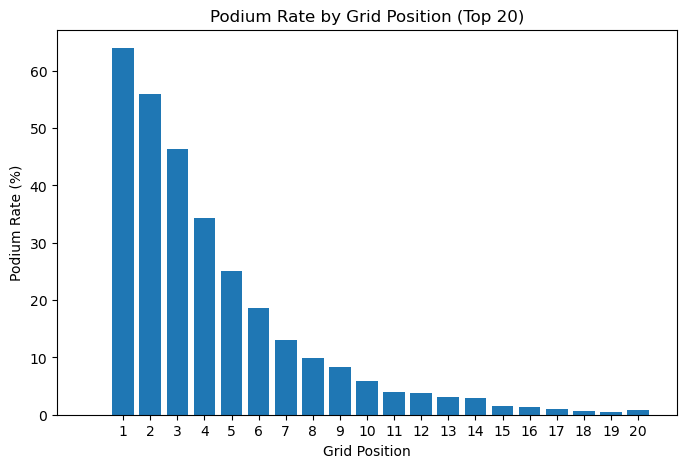

In [35]:
podium_by_grid = df.groupby('grid')['podium'].mean() * 100

top_grids = podium_by_grid[podium_by_grid.index <= 20]

plt.figure(figsize=(8,5))
plt.bar(top_grids.index, top_grids.values)

plt.title('Podium Rate by Grid Position (Top 20)')
plt.xlabel('Grid Position')
plt.ylabel('Podium Rate (%)')

plt.xticks(range(1,21))
plt.show()

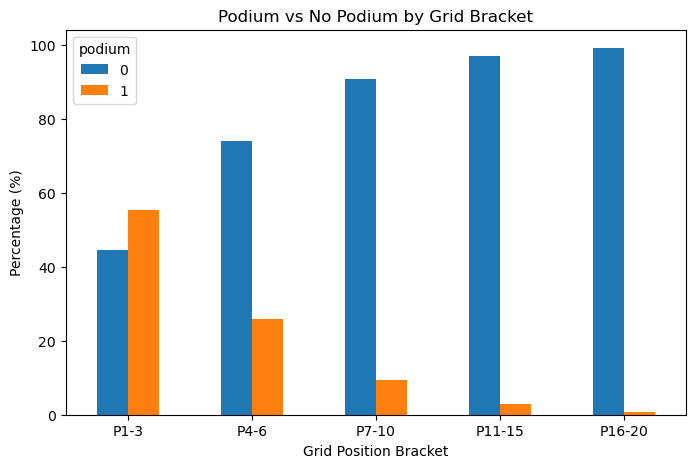

In [36]:
grid_cap = df[df['grid'] <= 20].copy()

grid_cap['grid_bin'] = pd.cut(
    grid_cap['grid'],
    bins=[0,3,6,10,15,20],
    labels=['P1-3','P4-6','P7-10','P11-15','P16-20']
)

pct = grid_cap.groupby(['grid_bin', 'podium']).size().unstack(fill_value=0)

pct_pct = pct.div(pct.sum(axis=1), axis=0) * 100

pct_pct.plot(kind='bar', figsize=(8,5))

plt.title('Podium vs No Podium by Grid Bracket')
plt.xlabel('Grid Position Bracket')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

plt.show()

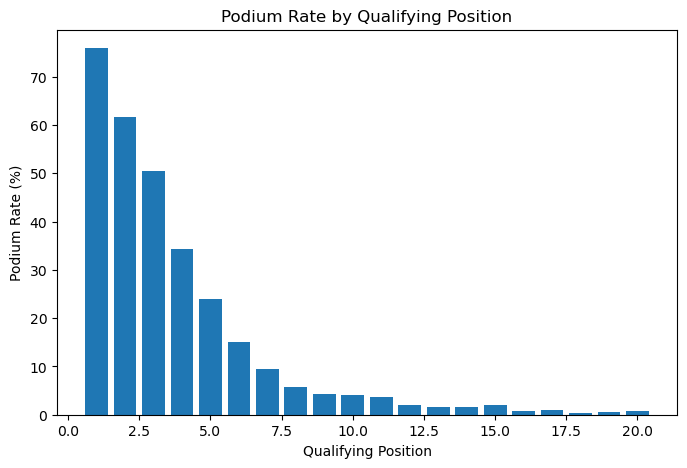

In [37]:
df_q = df[df['quali_position'].notna() & (df['quali_position'] <= 20)]

podium_by_quali = df_q.groupby('quali_position')['podium'].mean() * 100

plt.figure(figsize=(8,5))
plt.bar(podium_by_quali.index, podium_by_quali.values)

plt.title('Podium Rate by Qualifying Position')
plt.xlabel('Qualifying Position')
plt.ylabel('Podium Rate (%)')

plt.show()

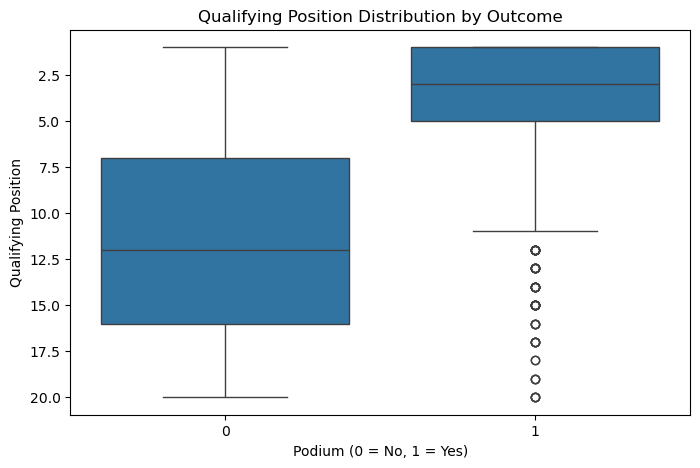

In [38]:
df_q = df[df['quali_position'].notna() & (df['quali_position'] <= 20)]

plt.figure(figsize=(8,5))
sns.boxplot(data=df_q, x='podium', y='quali_position')

plt.title('Qualifying Position Distribution by Outcome')
plt.xlabel('Podium (0 = No, 1 = Yes)')
plt.ylabel('Qualifying Position')

plt.gca().invert_yaxis()

plt.show()

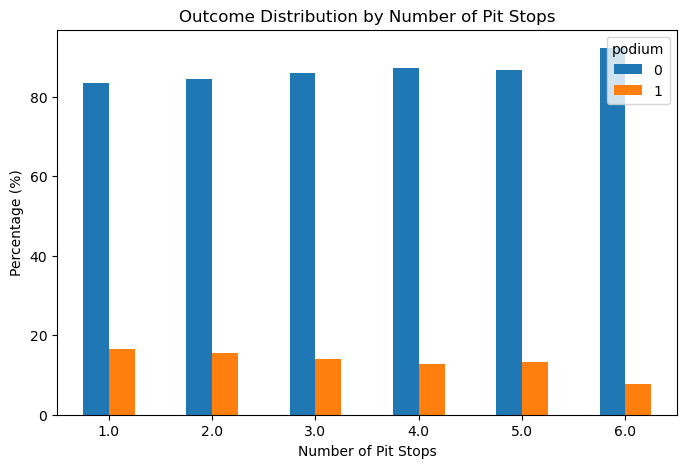

In [39]:
df_pit = df[df['num_pitstops'].notna()]

pit_podium = df_pit.groupby(['num_pitstops', 'podium']).size().unstack(fill_value=0)
pit_podium_pct = pit_podium.div(pit_podium.sum(axis=1), axis=0) * 100

valid_stops = pit_podium_pct[pit_podium_pct.index <= 6]

valid_stops.plot(kind='bar', figsize=(8,5))

plt.title('Outcome Distribution by Number of Pit Stops')
plt.xlabel('Number of Pit Stops')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

plt.show()

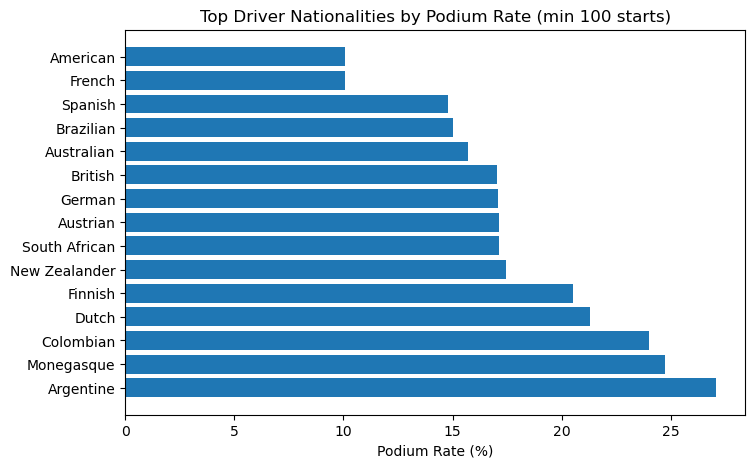

In [40]:
top_nat = df.groupby('nationality')['podium'].agg(['sum', 'count'])

top_nat['rate'] = top_nat['sum'] / top_nat['count'] * 100

top_nat = top_nat[top_nat['count'] >= 100].nlargest(15, 'rate')

plt.figure(figsize=(8,5))
plt.barh(top_nat.index, top_nat['rate'])

plt.title('Top Driver Nationalities by Podium Rate (min 100 starts)')
plt.xlabel('Podium Rate (%)')

plt.show()

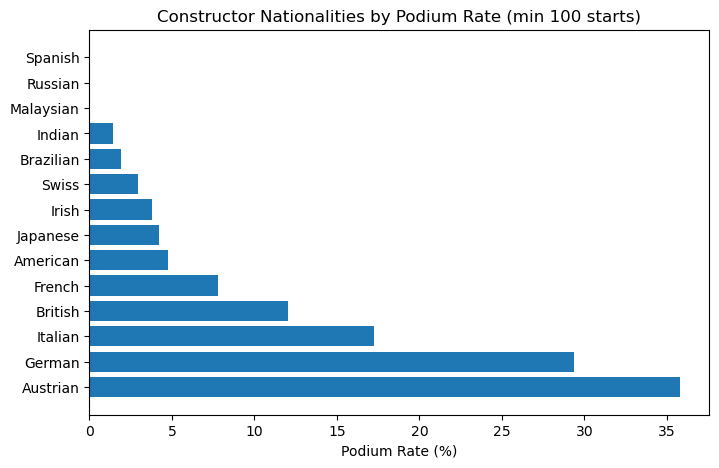

In [41]:
top_con = df.groupby('construct_nationality')['podium'].agg(['sum', 'count'])

top_con['rate'] = top_con['sum'] / top_con['count'] * 100

top_con = top_con[top_con['count'] >= 100].nlargest(15, 'rate')

plt.figure(figsize=(8,5))
plt.barh(top_con.index, top_con['rate'])

plt.title('Constructor Nationalities by Podium Rate (min 100 starts)')
plt.xlabel('Podium Rate (%)')

plt.show()

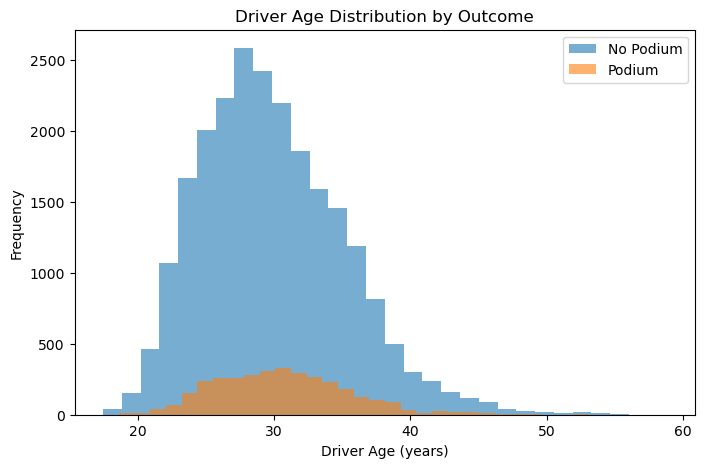

In [42]:
plt.figure(figsize=(8,5))

plt.hist(df[df['podium'] == 0]['driver_age'], bins=30, alpha=0.6, label='No Podium')
plt.hist(df[df['podium'] == 1]['driver_age'], bins=30, alpha=0.6, label='Podium')

plt.title('Driver Age Distribution by Outcome')
plt.xlabel('Driver Age (years)')
plt.ylabel('Frequency')
plt.legend()

plt.show()

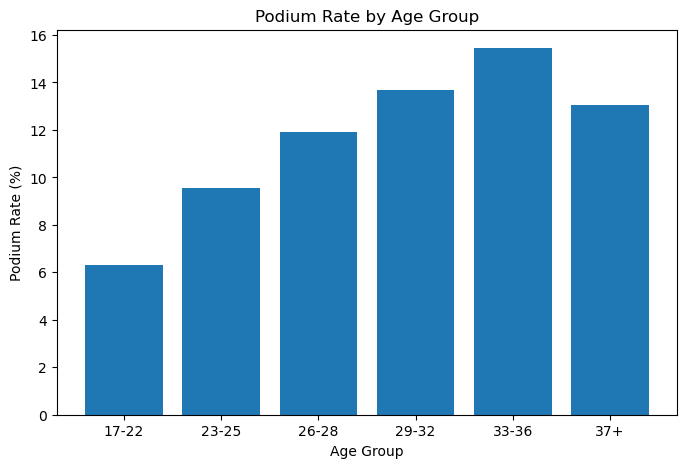

In [43]:
df['age_bin'] = pd.cut(
    df['driver_age'],
    bins=[17, 22, 25, 28, 32, 36, 50],
    labels=['17-22', '23-25', '26-28', '29-32', '33-36', '37+']
)

age_rate = df.groupby('age_bin')['podium'].mean() * 100

plt.figure(figsize=(8,5))
plt.bar(age_rate.index, age_rate.values)

plt.title('Podium Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Podium Rate (%)')

plt.show()

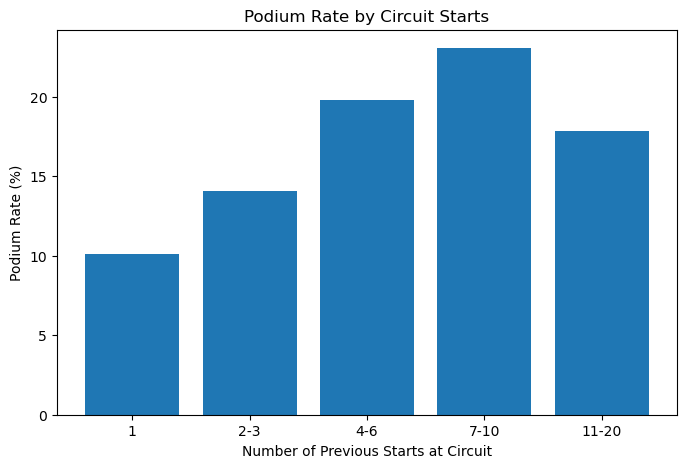

In [44]:
df['starts_bin'] = pd.cut(
    df['circuit_starts'],
    bins=[0,1,3,6,10,20,100],
    labels=['1','2-3','4-6','7-10','11-20','20+']
)

starts_rate = df.groupby('starts_bin')['podium'].mean() * 100

plt.figure(figsize=(8,5))
plt.bar(starts_rate.index, starts_rate.values)

plt.title('Podium Rate by Circuit Starts')
plt.xlabel('Number of Previous Starts at Circuit')
plt.ylabel('Podium Rate (%)')

plt.show()

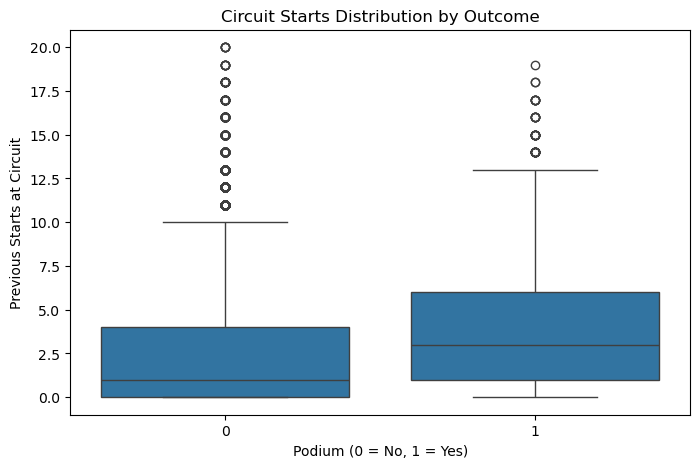

In [45]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='podium', y='circuit_starts')

plt.title('Circuit Starts Distribution by Outcome')
plt.xlabel('Podium (0 = No, 1 = Yes)')
plt.ylabel('Previous Starts at Circuit')

plt.show()

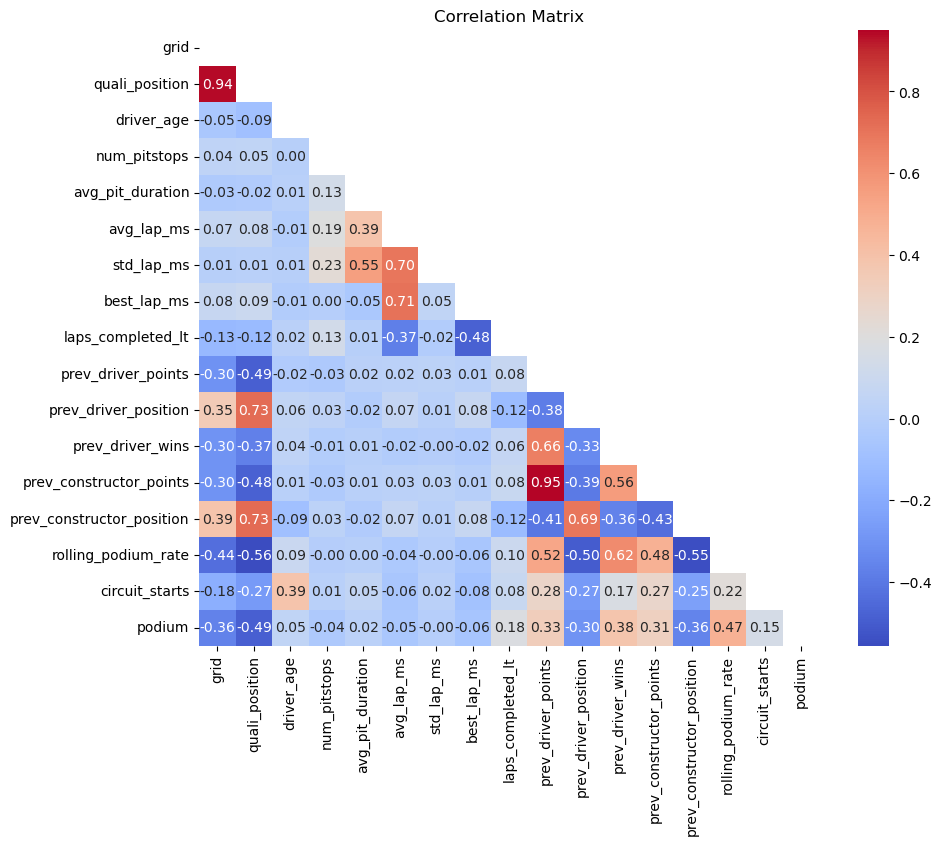

In [46]:
numeric_cols = [
    'grid', 'quali_position', 'driver_age', 'num_pitstops', 'avg_pit_duration',
    'avg_lap_ms', 'std_lap_ms', 'best_lap_ms', 'laps_completed_lt',
    'prev_driver_points', 'prev_driver_position', 'prev_driver_wins',
    'prev_constructor_points', 'prev_constructor_position',
    'rolling_podium_rate', 'circuit_starts', 'podium'
]
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10,8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

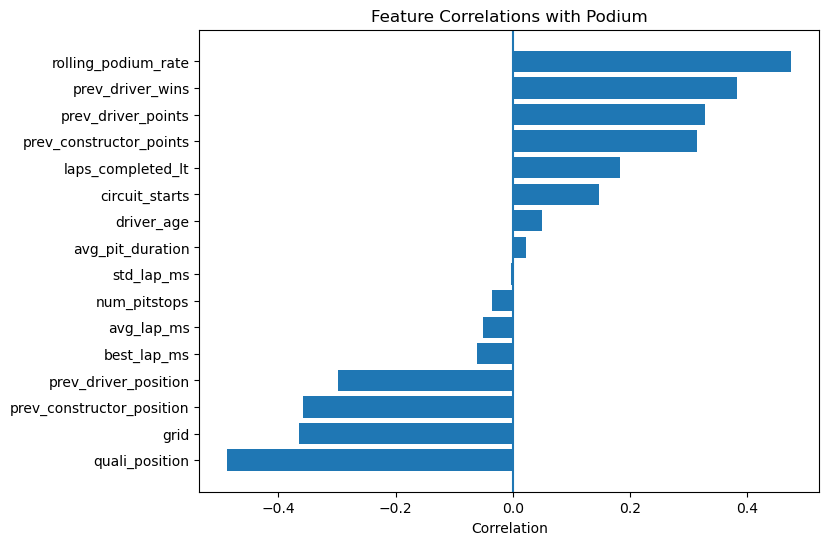

In [47]:
podium_corr = df[numeric_cols].corr()['podium'].drop('podium').sort_values()
plt.figure(figsize=(8,6))
plt.barh(podium_corr.index, podium_corr.values)
plt.axvline(0)
plt.title('Feature Correlations with Podium')
plt.xlabel('Correlation')
plt.show()

### MISSING VALUE ANALYSIS

In [48]:
feature_cols = ['grid','quali_position','driver_age','num_pitstops','avg_pit_duration',
                'min_pit_duration','avg_lap_ms','std_lap_ms','best_lap_ms',
                'prev_driver_points','prev_driver_position','prev_driver_wins',
                'prev_constructor_points','prev_constructor_position',
                'rolling_podium_rate','circuit_starts']

miss = df[feature_cols].isnull().mean().sort_values(ascending=False)
print('Missing value rates:')
print(miss[miss > 0])

Missing value rates:
num_pitstops                 0.790948
avg_pit_duration             0.790948
min_pit_duration             0.790948
quali_position               0.606495
std_lap_ms                   0.590295
avg_lap_ms                   0.585983
best_lap_ms                  0.585983
prev_constructor_points      0.076459
prev_constructor_position    0.076459
prev_driver_points           0.049610
prev_driver_position         0.049610
prev_driver_wins             0.049610
rolling_podium_rate          0.032286
dtype: float64


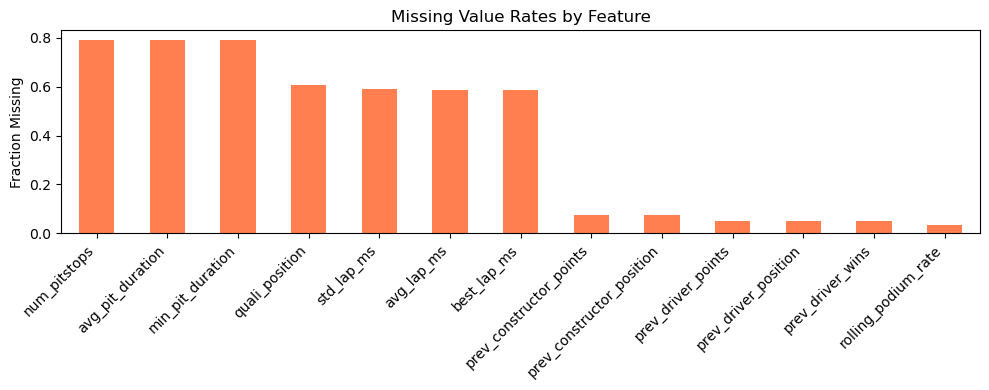

In [49]:
plt.figure(figsize=(10,4))
miss[miss > 0].plot(kind='bar', color='coral')
plt.title('Missing Value Rates by Feature')
plt.ylabel('Fraction Missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# DATA PREPERATION FOR MODELING

We filter to 2011+ (modern hybrid-era rules), apply a time-based 70/15/15 split, and build a preprocessing pipeline.

In [50]:
df = df.drop_duplicates(subset=['raceId', 'driverId'], keep='first')
print("df dupes:", df.duplicated(subset=['raceId', 'driverId']).sum())

df dupes: 0


In [51]:
df_2011 = df[df['year'] >= 2011].copy()

print(f"Filtered shape: {df_2011.shape}")
print(f"Years: {df_2011['year'].min()} → {df_2011['year'].max()}")
print(f"Podium rate: {df_2011['podium'].mean():.3f}")

Filtered shape: (5980, 47)
Years: 2011 → 2024
Podium rate: 0.143


In [52]:
target_col = 'podium'

Drop Leaked columns

In [53]:
drop_cols = ['podium','position','positionText','positionOrder','points','rank']
drop_cols = [c for c in drop_cols if c in df_2011.columns]

In [54]:
X = df_2011.drop(columns=drop_cols)
y = df_2011[target_col].astype(int)

print("\nDropped columns:", drop_cols)
print("X shape:", X.shape, "| y mean:", y.mean())


Dropped columns: ['podium', 'position', 'positionText', 'positionOrder', 'points', 'rank']
X shape: (5980, 41) | y mean: 0.14347826086956522


#### Time-Based Train / Validation / Test Split

| Split | Years | Purpose |
|---|---|---|
| Train | 2011–2020 | Model fitting |
| Validation | 2021–2022 | Hyperparameter tuning |
| Test | 2023+ | Final evaluation |

In [55]:
train_df = df_2011[df_2011['year'] <= 2020].copy()
val_df   = df_2011[(df_2011['year'] >= 2021) & (df_2011['year'] <= 2022)].copy()
test_df  = df_2011[df_2011['year'] >= 2023].copy()

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target_col].astype(int)

X_val   = val_df.drop(columns=drop_cols)
y_val   = val_df[target_col].astype(int)

X_test  = test_df.drop(columns=drop_cols)
y_test  = test_df[target_col].astype(int)

print(f"Train : {X_train.shape}  podium rate: {y_train.mean():.3f}")
print(f"Val   : {X_val.shape}   podium rate: {y_val.mean():.3f}")
print(f"Test  : {X_test.shape}  podium rate: {y_test.mean():.3f}")

Train : (4181, 41)  podium rate: 0.141
Val   : (880, 41)   podium rate: 0.150
Test  : (919, 41)  podium rate: 0.150


### Preprocessing Pipeline

Numeric columns → median imputation → standard scaling  
Categorical columns → mode imputation → one-hot encoding

In [56]:
num_cols = X_train.select_dtypes(include=['int64','int32','float64','float32']).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

print(f"Numeric columns : {len(num_cols)}")
print(f"Categorical cols: {len(cat_cols)}")

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot",  OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ],
    remainder="drop"
)

Numeric columns : 27
Categorical cols: 14


### Clean Raw Data for all the Models



In [57]:
X_train = X_train.replace('\\N', np.nan).apply(lambda col: col.map(convert_time_to_ms))
X_val   = X_val.replace('\\N', np.nan).apply(lambda col: col.map(convert_time_to_ms))
X_test  = X_test.replace('\\N', np.nan).apply(lambda col: col.map(convert_time_to_ms))

X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_val   = X_val.apply(pd.to_numeric, errors='coerce')
X_test  = X_test.apply(pd.to_numeric, errors='coerce')

col_means = X_train.mean()
X_train = X_train.fillna(col_means)
X_val   = X_val.fillna(col_means)
X_test  = X_test.fillna(col_means)

In [58]:
def clean_for_tree(X_tr, X_te):
    X_tr = X_tr.replace('\\N', np.nan).apply(pd.to_numeric, errors='coerce')
    X_te = X_te.replace('\\N', np.nan).apply(pd.to_numeric, errors='coerce')
    col_means = X_tr.mean()
    return X_tr.fillna(col_means), X_te.fillna(col_means)

tree_leakage = ['position_num', 'quali_position']

def drop_if_present(X, cols):
    return X.drop(columns=[c for c in cols if c in X.columns])

X_train_tree, X_test_tree = clean_for_tree(
    drop_if_present(X_train, tree_leakage),
    drop_if_present(X_test,  tree_leakage),
)
print("Tree feature set:", X_train_tree.shape[1], "columns")

Tree feature set: 39 columns


In [59]:
leakage_cols = ['position_num', 'quali_position']
X_train = X_train.drop(columns=[c for c in leakage_cols if c in X_train.columns])
X_val   = X_val.drop(columns=[c for c in leakage_cols if c in X_val.columns])
X_test  = X_test.drop(columns=[c for c in leakage_cols if c in X_test.columns])

In [60]:
num_cols = X_train.select_dtypes(include=['int64','int32','float64','float32']).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

print(f"Numeric columns : {len(num_cols)}")
print(f"Categorical cols: {len(cat_cols)}")

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot",  OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ],
    remainder="drop"
)

Numeric columns : 39
Categorical cols: 0


# MODEL TRAINING AND EVALUATION

In [61]:
results = {}   

def store_results(name, y_true, y_pred):
    from sklearn.metrics import f1_score, precision_score, recall_score
    results[name] = {
        'Test Accuracy': accuracy_score(y_true, y_pred),
        'F1 (podium)':   f1_score(y_true, y_pred),
        'Precision':     precision_score(y_true, y_pred, zero_division=0),
        'Recall':        recall_score(y_true, y_pred),
    }

### Logistic Regression

In [62]:
logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)

print("── Logistic Regression ──")
print(f"Train accuracy : {logreg.score(X_train, y_train):.4f}")
print(f"Val accuracy   : {logreg.score(X_val,   y_val  ):.4f}")
print(f"Test accuracy  : {logreg.score(X_test,  y_test ):.4f}")
print(classification_report(y_test, y_pred_lr, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
store_results("Logistic Regression", y_test, y_pred_lr)

── Logistic Regression ──
Train accuracy : 0.8811
Val accuracy   : 0.8795
Test accuracy  : 0.8292
              precision    recall  f1-score   support

           0     0.9727    0.8220    0.8910       781
           1     0.4633    0.8696    0.6045       138

    accuracy                         0.8292       919
   macro avg     0.7180    0.8458    0.7478       919
weighted avg     0.8962    0.8292    0.8480       919

Confusion Matrix:
 [[642 139]
 [ 18 120]]


### Decision Tree (Default)

── Decision Tree (Default) ──
Train accuracy : 1.0000
Val accuracy   : 0.9114
Test accuracy  : 0.8662
              precision    recall  f1-score   support

           0     0.9470    0.8924    0.9189       781
           1     0.5410    0.7174    0.6168       138

    accuracy                         0.8662       919
   macro avg     0.7440    0.8049    0.7679       919
weighted avg     0.8860    0.8662    0.8736       919

Confusion Matrix:
 [[697  84]
 [ 39  99]]


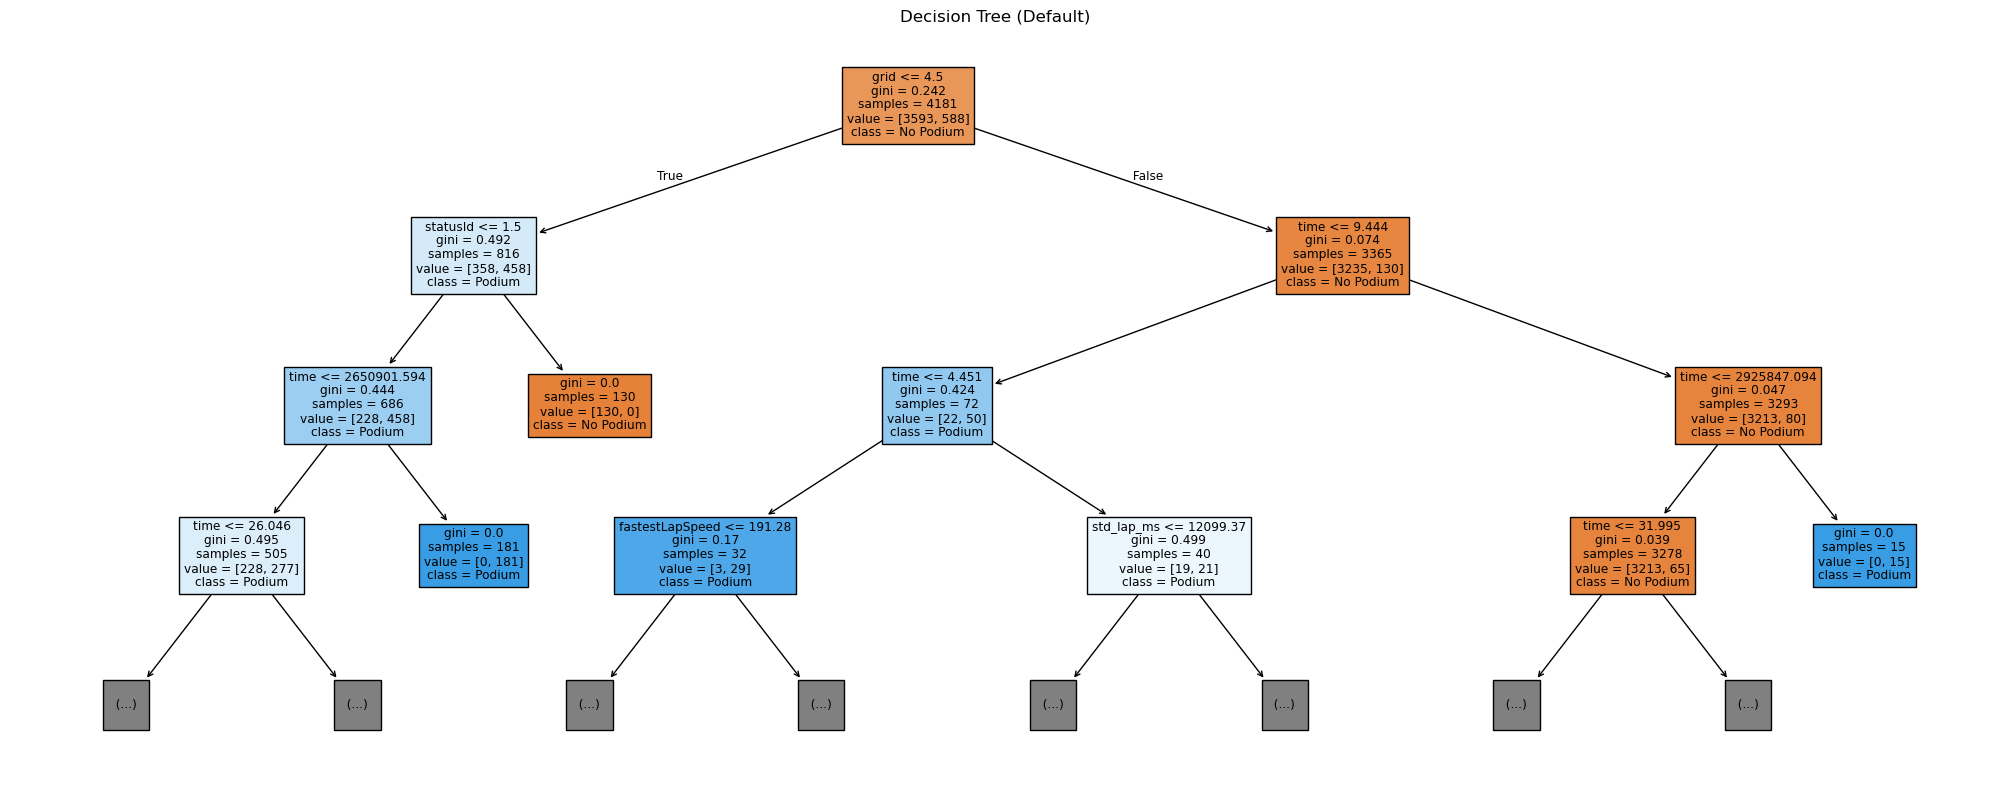

In [63]:
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)
y_pred_dt = decision_tree.predict(X_test)

print("── Decision Tree (Default) ──")
print(f"Train accuracy : {decision_tree.score(X_train, y_train):.4f}")
print(f"Val accuracy   : {decision_tree.score(X_val,   y_val  ):.4f}")
print(f"Test accuracy  : {decision_tree.score(X_test,  y_test ):.4f}")
print(classification_report(y_test, y_pred_dt, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
store_results("Decision Tree", y_test, y_pred_dt)

plt.figure(figsize=(20, 8))
plot_tree(decision_tree, max_depth=3, feature_names=X_train.columns,
          class_names=['No Podium', 'Podium'], filled=True)
plt.title('Decision Tree (Default)')
plt.tight_layout()
plt.show()

### Decision Tree (Tuned)

── Decision Tree (Tuned) ──
Train accuracy : 0.9569
Val accuracy   : 0.9295
Test accuracy  : 0.9402
              precision    recall  f1-score   support

           0     0.9654    0.9641    0.9648       781
           1     0.7986    0.8043    0.8014       138

    accuracy                         0.9402       919
   macro avg     0.8820    0.8842    0.8831       919
weighted avg     0.9403    0.9402    0.9402       919

Confusion Matrix:
 [[753  28]
 [ 27 111]]


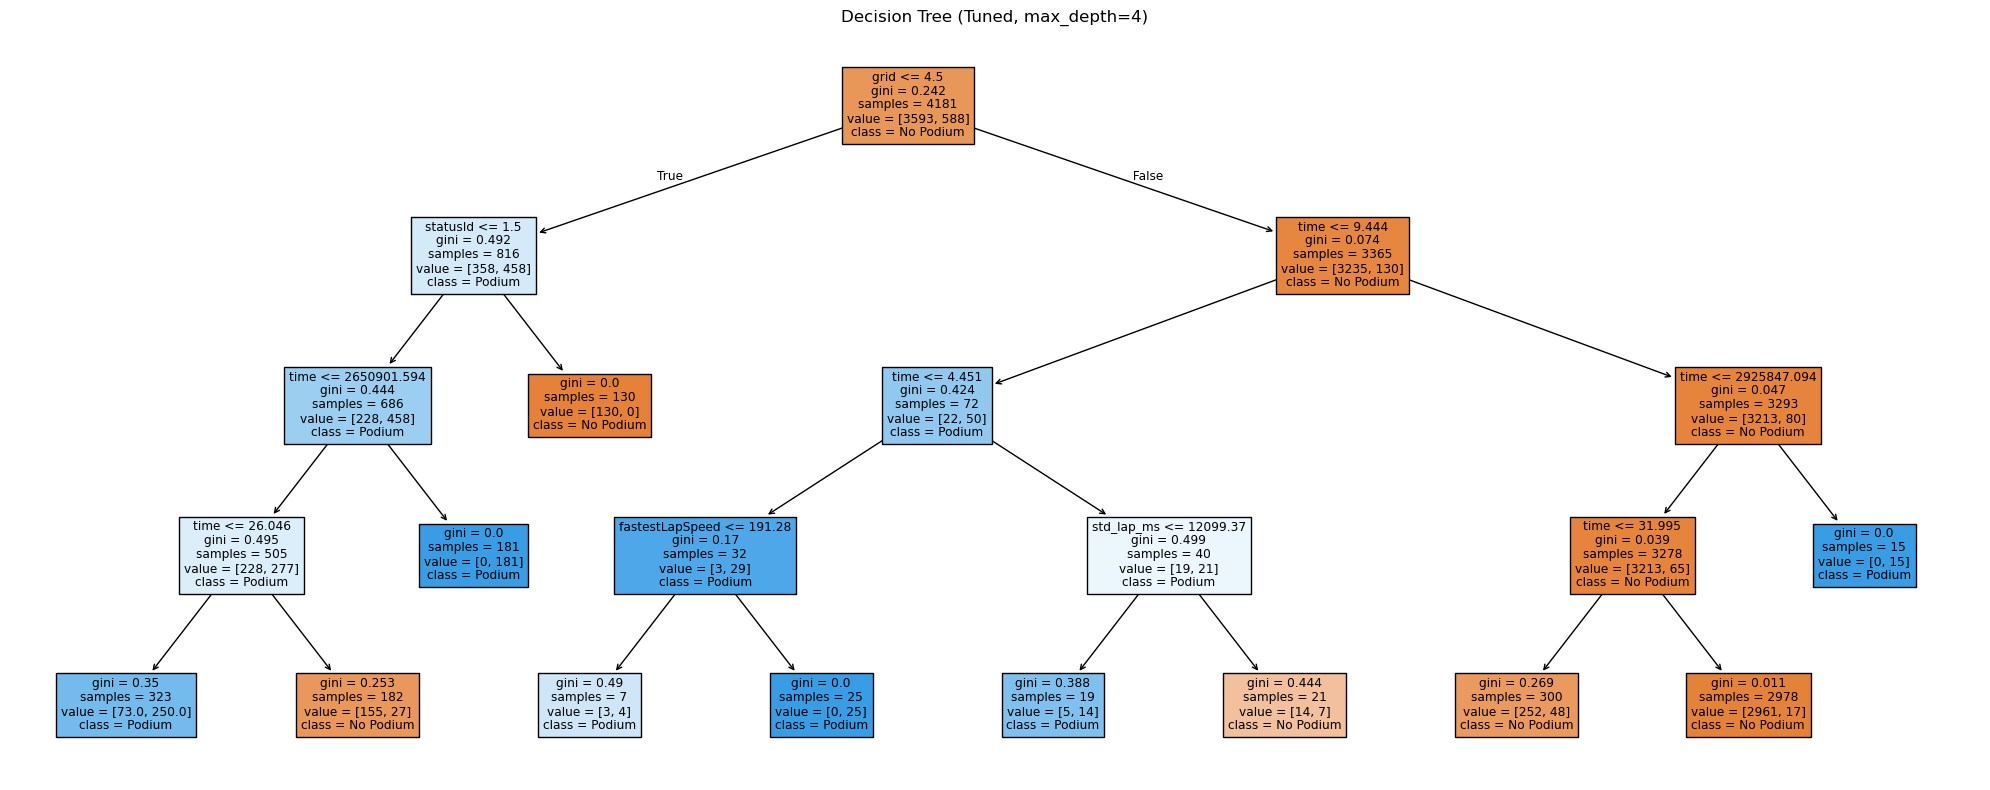

In [64]:
dt_tuned = DecisionTreeClassifier(max_depth=4, min_samples_split=8,
                                   min_samples_leaf=2, random_state=42)
dt_tuned.fit(X_train, y_train)
y_pred_dt_tuned = dt_tuned.predict(X_test)

print("── Decision Tree (Tuned) ──")
print(f"Train accuracy : {dt_tuned.score(X_train, y_train):.4f}")
print(f"Val accuracy   : {dt_tuned.score(X_val,   y_val  ):.4f}")
print(f"Test accuracy  : {dt_tuned.score(X_test,  y_test ):.4f}")
print(classification_report(y_test, y_pred_dt_tuned, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt_tuned))
store_results("Decision Tree (Tuned)", y_test, y_pred_dt_tuned)

plt.figure(figsize=(20, 8))
plot_tree(dt_tuned, feature_names=X_train.columns,
          class_names=['No Podium', 'Podium'], filled=True)
plt.title('Decision Tree (Tuned, max_depth=4)')
plt.tight_layout()
plt.show()

### Random Forest

In [65]:
random_forest = RandomForestClassifier(n_estimators=100, max_depth=5,
                                        min_samples_split=8, min_samples_leaf=2,
                                        random_state=42)
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)

print("── Random Forest ──")
print(f"Train accuracy : {random_forest.score(X_train, y_train):.4f}")
print(f"Val accuracy   : {random_forest.score(X_val,   y_val  ):.4f}")
print(f"Test accuracy  : {random_forest.score(X_test,  y_test ):.4f}")
print(classification_report(y_test, y_pred_rf, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
store_results("Random Forest", y_test, y_pred_rf)

── Random Forest ──
Train accuracy : 0.9514
Val accuracy   : 0.9284
Test accuracy  : 0.9184
              precision    recall  f1-score   support

           0     0.9347    0.9718    0.9529       781
           1     0.7944    0.6159    0.6939       138

    accuracy                         0.9184       919
   macro avg     0.8646    0.7939    0.8234       919
weighted avg     0.9137    0.9184    0.9140       919

Confusion Matrix:
 [[759  22]
 [ 53  85]]


### K-Nearest Neighbors

In [66]:
knn = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("── KNN ──")
print(f"Train accuracy : {knn.score(X_train, y_train):.4f}")
print(f"Val accuracy   : {knn.score(X_val,   y_val  ):.4f}")
print(f"Test accuracy  : {knn.score(X_test,  y_test ):.4f}")
print(classification_report(y_test, y_pred_knn, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
store_results("KNN", y_test, y_pred_knn)


── KNN ──
Train accuracy : 0.9354
Val accuracy   : 0.9080
Test accuracy  : 0.8792
              precision    recall  f1-score   support

           0     0.9219    0.9373    0.9295       781
           1     0.6080    0.5507    0.5779       138

    accuracy                         0.8792       919
   macro avg     0.7650    0.7440    0.7537       919
weighted avg     0.8748    0.8792    0.8767       919

Confusion Matrix:
 [[732  49]
 [ 62  76]]


### Support Vector Machine

In [67]:
svm_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced"))
])

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("── SVM ──")
print(f"Train accuracy : {svm_model.score(X_train, y_train):.4f}")
print(f"Val accuracy   : {svm_model.score(X_val,   y_val  ):.4f}")
print(f"Test accuracy  : {svm_model.score(X_test,  y_test ):.4f}")
print(classification_report(y_test, y_pred_svm, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
store_results("SVM", y_test, y_pred_svm)

── SVM ──
Train accuracy : 0.8936
Val accuracy   : 0.8989
Test accuracy  : 0.8477
              precision    recall  f1-score   support

           0     0.9508    0.8656    0.9062       781
           1     0.4952    0.7464    0.5954       138

    accuracy                         0.8477       919
   macro avg     0.7230    0.8060    0.7508       919
weighted avg     0.8824    0.8477    0.8595       919

Confusion Matrix:
 [[676 105]
 [ 35 103]]


### XGBoost

In [88]:
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb = Pipeline([
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss", random_state=42,
    )),
])

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("── XGBoost ──")
print(f"Train accuracy : {accuracy_score(y_train, xgb.predict(X_train)):.4f}")
print(f"Val accuracy   : {accuracy_score(y_val, xgb.predict(X_val)):.4f}")
print(f"Test accuracy  : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, digits=4))
store_results("XGBoost", y_test, y_pred_xgb)

── XGBoost ──
Train accuracy : 0.9914
Val accuracy   : 0.9318
Test accuracy  : 0.9325
              precision    recall  f1-score   support

           0     0.9724    0.9475    0.9598       781
           1     0.7405    0.8478    0.7905       138

    accuracy                         0.9325       919
   macro avg     0.8565    0.8977    0.8752       919
weighted avg     0.9376    0.9325    0.9344       919



### AdaBoost

In [69]:
ada = Pipeline([
    ("preprocess", preprocess),
    ("model", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2),
        n_estimators=200, learning_rate=0.1, random_state=42,
    )),
])

ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

print("── AdaBoost ──")
print(f"Train accuracy : {accuracy_score(y_train, ada.predict(X_train)):.4f}")
print(f"Val accuracy   : {accuracy_score(y_val, ada.predict(X_val)):.4f}")
print(f"Test accuracy  : {accuracy_score(y_test, y_pred_ada):.4f}")
print(classification_report(y_test, y_pred_ada, digits=4))
store_results("AdaBoost", y_test, y_pred_ada)

── AdaBoost ──
Train accuracy : 0.9572
Val accuracy   : 0.9432
Test accuracy  : 0.9489
              precision    recall  f1-score   support

           0     0.9657    0.9744    0.9700       781
           1     0.8473    0.8043    0.8253       138

    accuracy                         0.9489       919
   macro avg     0.9065    0.8894    0.8977       919
weighted avg     0.9480    0.9489    0.9483       919



# Confusion Matrices

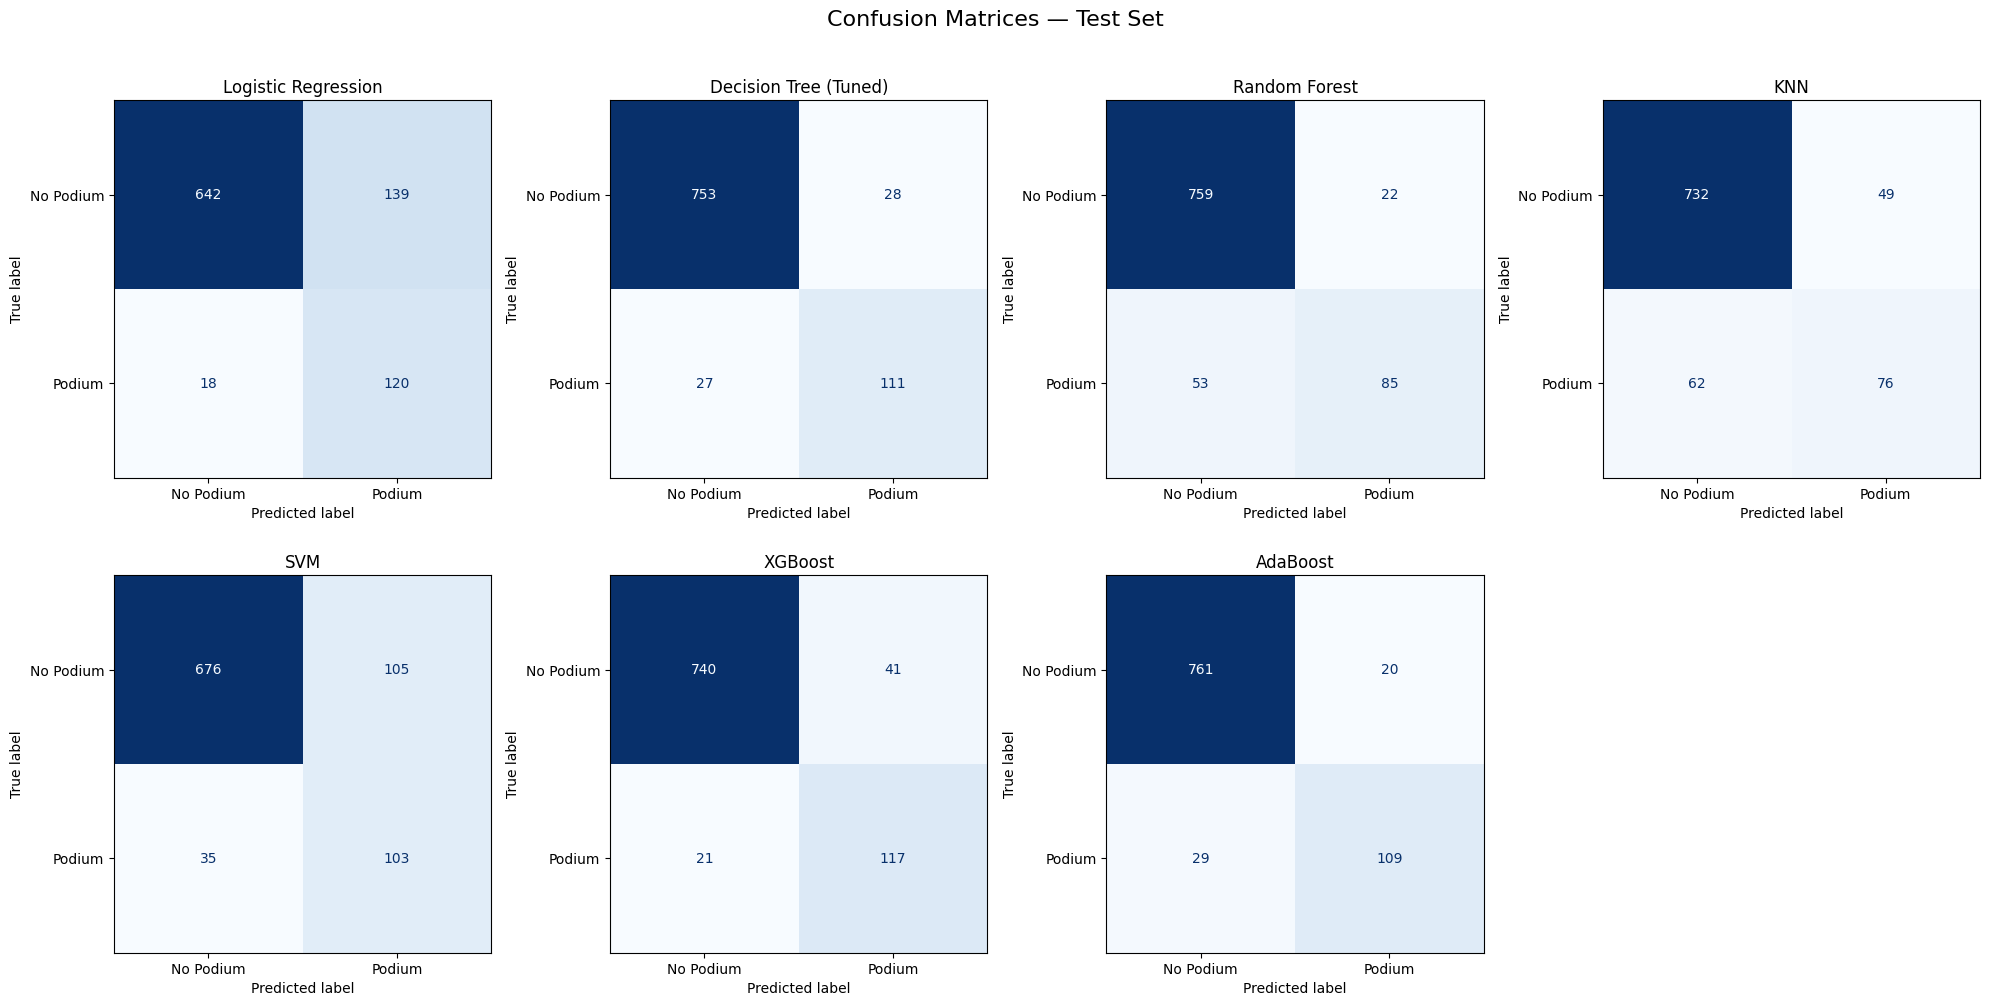

In [89]:
def plot_conf_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Podium", "Podium"])
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    ax.grid(False)

model_preds = [
    ("Logistic Regression",    y_pred_lr),
    ("Decision Tree (Tuned)",  y_pred_dt_tuned),
    ("Random Forest",          y_pred_rf),
    ("KNN",                    y_pred_knn),
    ("SVM",                    y_pred_svm),
    ("XGBoost",                y_pred_xgb),
    ("AdaBoost",               y_pred_ada),
]

n = len(model_preds)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, pred) in enumerate(model_preds):
    plot_conf_matrix(y_test, pred, name, axes[i])

axes[-1].set_visible(False)

plt.suptitle('Confusion Matrices — Test Set', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# Model Comparison

In [90]:
results_df = pd.DataFrame(results).T.round(4)
results_df.index.name = 'Model'
results_df = results_df.sort_values('Test Accuracy', ascending=False)

styled = (
    results_df.style
    .highlight_max(axis=0, color="#e02626")
    .format("{:.4f}")
    .set_caption("Model Performance on Test Set (2023+)")
)
display(styled)

,Test Accuracy,F1 (podium),Precision,Recall
Model,,,,
AdaBoost,0.9467,0.8165,0.8450,0.7899
Decision Tree (Tuned),0.9402,0.8014,0.7986,0.8043
XGBoost,0.9325,0.7905,0.7405,0.8478
Random Forest,0.9184,0.6939,0.7944,0.6159
KNN,0.8792,0.5779,0.6080,0.5507
Decision Tree,0.8640,0.6224,0.5337,0.7464
SVM,0.8477,0.5954,0.4952,0.7464
Logistic Regression,0.8292,0.6045,0.4633,0.8696


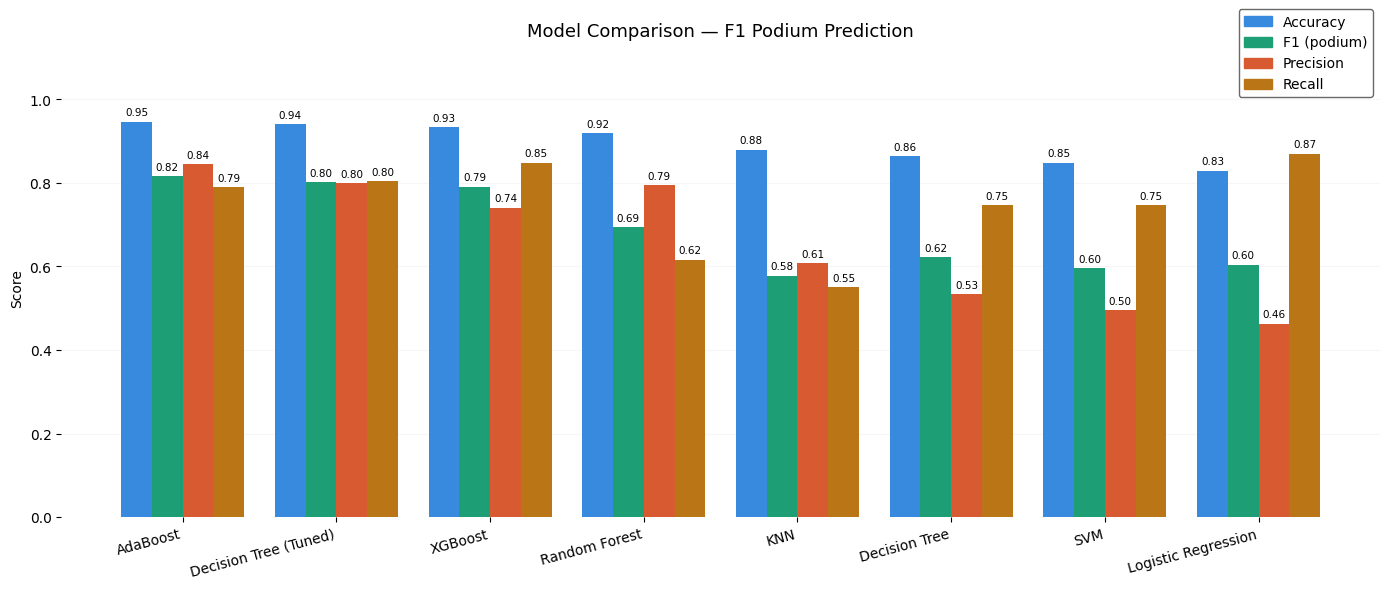

In [101]:
models = results_df.index.tolist()
accuracy  = results_df['Test Accuracy'].tolist()
f1        = results_df['F1 (podium)'].tolist()
precision = results_df['Precision'].tolist()
recall    = results_df['Recall'].tolist()

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(color="white")
ax.set_facecolor(color="white")

bars1 = ax.bar(x - 1.5*width, accuracy,  width, label='Accuracy',    color='#378ADD', zorder=3)
bars2 = ax.bar(x - 0.5*width, f1,        width, label='F1 (podium)', color='#1D9E75', zorder=3)
bars3 = ax.bar(x + 0.5*width, precision, width, label='Precision',   color='#D85A30', zorder=3)
bars4 = ax.bar(x + 1.5*width, recall,    width, label='Recall',      color='#BA7517', zorder=3)

# Value labels on top of bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom',
                fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.yaxis.set_tick_params()
ax.set_title('Model Comparison — F1 Podium Prediction',fontsize=13, pad=15)
ax.grid(axis='y',  alpha=0.1, zorder=0)
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.tick_params()

legend = ax.legend(
    handles=[
        mpatches.Patch(color='#378ADD', label='Accuracy'),
        mpatches.Patch(color='#1D9E75', label='F1 (podium)'),
        mpatches.Patch(color='#D85A30', label='Precision'),
        mpatches.Patch(color='#BA7517', label='Recall'),
    ],
    loc='upper right', bbox_to_anchor=(1.0, 1.12), edgecolor='#444',  fontsize=10
)

plt.tight_layout()
plt.show()

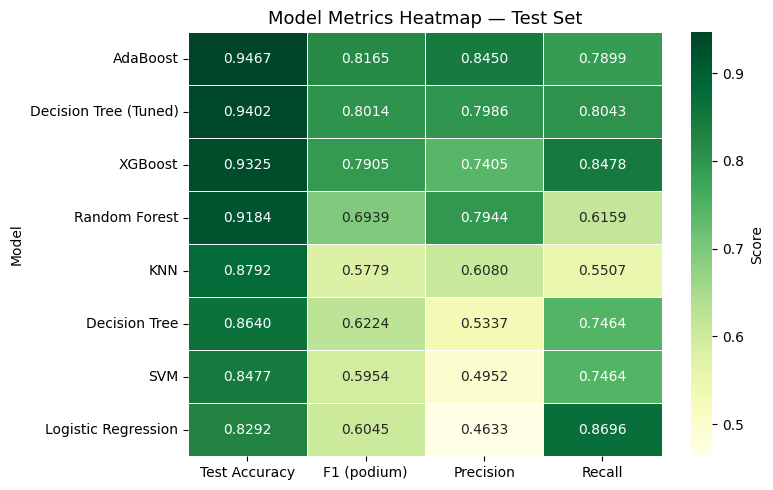

In [92]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    results_df,
    annot=True, fmt='.4f', cmap='YlGn',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Score'},
)
plt.title('Model Metrics Heatmap — Test Set', fontsize=13)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ADABOOST PREDICTIONS RACE BY RACE

In [75]:
test_df_info = df_2011[df_2011['year'] >= 2023].copy().reset_index(drop=True)

In [76]:
assert len(test_df_info) == len(X_test), "Row mismatch — rerun from df_2011 split cell!"
test_df_info['predicted_podium_prob'] = ada.predict_proba(X_test)[:, 1]
test_df_info['predicted_podium']      = ada.predict(X_test)
test_df_info['actual_podium']         = y_test.reset_index(drop=True)

In [77]:
races_list = (
    test_df_info[['year', 'name', 'date']]
    .drop_duplicates()
    .sort_values(['year', 'date'])
)

In [78]:
print(f"{'='*70}")
print(f"{'ADABOOST PREDICTIONS vs ACTUAL — RACE BY RACE':^70}")
print(f"{'='*70}\n")

for _, race_row in races_list.iterrows():
    race_data = test_df_info[
        (test_df_info['name'] == race_row['name']) & 
        (test_df_info['year'] == race_row['year']) 
    ].copy()

    actual_top3 = (
        race_data[(race_data['actual_podium'] == 1) & (race_data['position_num'].notna())]
        .sort_values('position_num')
        .head(3)['driver_name']
        .tolist()
    )

    predicted_top3 = (
        race_data
        .sort_values('predicted_podium_prob', ascending=False)
        .head(3)['driver_name']
        .tolist()
    )

    correct = len(set(actual_top3) & set(predicted_top3))

    print(f"📍 {race_row['name']} {int(race_row['year'])}")
    print(f"   Actual top 3    : {', '.join(actual_top3) if actual_top3 else 'N/A'}")
    print(f"   Predicted top 3 : {', '.join(predicted_top3)}")
    print(f"   Correct drivers : {correct}/3")
    print()

            ADABOOST PREDICTIONS vs ACTUAL — RACE BY RACE             

📍 Bahrain Grand Prix 2023
   Actual top 3    : Max Verstappen, Sergio Pérez, Fernando Alonso
   Predicted top 3 : Max Verstappen, Sergio Pérez, Carlos Sainz
   Correct drivers : 2/3

📍 Saudi Arabian Grand Prix 2023
   Actual top 3    : Sergio Pérez, Max Verstappen, Fernando Alonso
   Predicted top 3 : Sergio Pérez, Max Verstappen, Fernando Alonso
   Correct drivers : 3/3

📍 Australian Grand Prix 2023
   Actual top 3    : Max Verstappen, Lewis Hamilton, Fernando Alonso
   Predicted top 3 : Max Verstappen, Sergio Pérez, Lewis Hamilton
   Correct drivers : 2/3

📍 Azerbaijan Grand Prix 2023
   Actual top 3    : Sergio Pérez, Max Verstappen, Charles Leclerc
   Predicted top 3 : Sergio Pérez, Max Verstappen, Charles Leclerc
   Correct drivers : 3/3

📍 Miami Grand Prix 2023
   Actual top 3    : Max Verstappen, Sergio Pérez, Fernando Alonso
   Predicted top 3 : Max Verstappen, Sergio Pérez, Fernando Alonso
   Correct drive

In [ ]:
race_rows = []
for _, race_row in races_list.iterrows():
    race_data = test_df_info[
        (test_df_info['name'] == race_row['name']) &
        (test_df_info['year'] == race_row['year'])
    ].copy()

    actual_top3 = (
        race_data[(race_data['actual_podium'] == 1) & (race_data['position_num'].notna())]
        .sort_values('position_num').head(3)['driver_name'].tolist()
    )
    predicted_top3 = (
        race_data.sort_values('predicted_podium_prob', ascending=False)
        .head(3)['driver_name'].tolist()
    )
    correct = len(set(actual_top3) & set(predicted_top3))
    race_rows.append({
        'race': f"{race_row['name']} {int(race_row['year'])}",
        'actual': actual_top3,
        'predicted': predicted_top3,
        'correct': correct
    })

races_json = json.dumps(race_rows)

html = f"""
<div style="font-family:sans-serif;max-width:100%">
<div style="display:flex;gap:10px;margin-bottom:1rem;flex-wrap:wrap">
  <input id="search" type="text" placeholder="Search race..." style="flex:1;min-width:180px;padding:6px 10px;border:0.5px solid #ccc;border-radius:6px;font-size:13px">
  <select id="filter" style="padding:6px 10px;border:0.5px solid #ccc;border-radius:6px;font-size:13px">
    <option value="all">All results</option>
    <option value="3">Perfect (3/3)</option>
    <option value="2">Good (2/3)</option>
    <option value="1">Partial (1/3)</option>
    <option value="0">Miss (0/3)</option>
  </select>
</div>
<div id="summary" style="display:grid;grid-template-columns:repeat(4,1fr);gap:8px;margin-bottom:1.2rem"></div>
<div id="race-list"></div>
</div>
<script>
const races = {races_json};

function colorFor(n) {{
  return n===3?'#1D9E75': n===2?'#378ADD': n===1?'#BA7517':'#E24B4A';
}}

function render(data) {{
  const list = document.getElementById('race-list');
  list.innerHTML = '';
  data.forEach(r => {{
    const c = colorFor(r.correct);
    list.innerHTML += `
    <div style="border:0.5px solid #ddd;border-radius:10px;padding:.85rem 1rem;margin-bottom:8px;border-left:3px solid ${{c}}">
      <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:6px">
        <span style="font-weight:500;font-size:14px">${{r.race}}</span>
        <span style="font-size:12px;font-weight:500;color:${{c}}">${{r.correct}}/3</span>
      </div>
      <div style="display:grid;grid-template-columns:1fr 1fr;gap:8px;font-size:12px;color:#666">
        <div><div style="margin-bottom:3px;color:#444;font-weight:500">Actual top 3</div>${{r.actual.map((d,i)=>`<div>${{i+1}}. ${{d}}</div>`).join('')}}</div>
        <div><div style="margin-bottom:3px;color:#444;font-weight:500">Predicted top 3</div>${{r.predicted.map((d,i)=>`<div style="color:${{r.actual.includes(d)?'#1D9E75':'#E24B4A'}}">${{i+1}}. ${{d}}</div>`).join('')}}</div>
      </div>
    </div>`;
  }});

  const totals = [0,0,0,0];
  data.forEach(r => totals[r.correct]++);
  const avg = data.length ? (data.reduce((s,r)=>s+r.correct,0)/(data.length*3)*100).toFixed(1) : 0;
  document.getElementById('summary').innerHTML = `
    <div style="background:#f5f5f3;border-radius:8px;padding:.75rem 1rem"><p style="font-size:11px;color:#888;margin:0 0 3px">Races shown</p><p style="font-size:20px;font-weight:500;margin:0">${{data.length}}</p></div>
    <div style="background:#f5f5f3;border-radius:8px;padding:.75rem 1rem"><p style="font-size:11px;color:#888;margin:0 0 3px">Perfect (3/3)</p><p style="font-size:20px;font-weight:500;margin:0;color:#1D9E75">${{totals[3]}}</p></div>
    <div style="background:#f5f5f3;border-radius:8px;padding:.75rem 1rem"><p style="font-size:11px;color:#888;margin:0 0 3px">Miss (0/3)</p><p style="font-size:20px;font-weight:500;margin:0;color:#E24B4A">${{totals[0]}}</p></div>
    <div style="background:#f5f5f3;border-radius:8px;padding:.75rem 1rem"><p style="font-size:11px;color:#888;margin:0 0 3px">Driver hit rate</p><p style="font-size:20px;font-weight:500;margin:0">${{avg}}%</p></div>`;
}}

function filtered() {{
  const q = document.getElementById('search').value.toLowerCase();
  const f = document.getElementById('filter').value;
  return races.filter(r =>
    r.race.toLowerCase().includes(q) &&
    (f==='all' || r.correct===+f)
  );
}}

document.getElementById('search').addEventListener('input', () => render(filtered()));
document.getElementById('filter').addEventListener('change', () => render(filtered()));
render(races);
</script>
"""
HTML(html)
